# Predicción de Churn en Telco — 02 · Experimentos y selección de modelos

Comparación sistemática de modelos para predecir churn, según el esquema definido en el EDA:

- **Partición:** 80% train / 20% test, estratificada por `Churn`, semilla fija.
  El test **no se toca** en este notebook: toda la comparación se hace con validación
  cruzada estratificada de 5 folds sobre train.
- **Métricas:** **PR-AUC** (average precision) como métrica principal de comparación
  (baseline teórico = prevalencia ≈ 0,265) y **F2 máximo** sobre predicciones out-of-fold
  como métrica secundaria (prioriza recall: perder un cliente sin intentar retenerlo cuesta
  más que una acción de retención de más).
- **Configuraciones:** cada modelo se evalúa con dos sets de features —
  `base` (limpieza + encoding estándar) y `enriquecida` (feature engineering derivado del EDA) —
  para que la comparación sea justa entre familias de modelos.

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.metrics import average_precision_score, precision_recall_curve

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore", message="X does not have valid feature names")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
SEED = 42

## 1. Carga, limpieza y partición

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Limpieza definida en el EDA (01_eda.ipynb)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)

X = df.drop(columns=["customerID", "Churn"])
y = (df["Churn"] == "Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"Train: {X_train.shape} (churn {y_train.mean():.3f}) | "
      f"Test: {X_test.shape} (churn {y_test.mean():.3f})")

Train: (5634, 19) (churn 0.265) | Test: (1409, 19) (churn 0.265)


## 2. Configuraciones de features

**`base`:** one-hot para categóricas + estandarización de numéricas. Sin transformaciones adicionales.

**`enriquecida`:** aplica el feature engineering sugerido por el EDA:
- `n_servicios`: cantidad de servicios contratados (churn decrece al aumentar).
- `tenure_banda` y su interacción con `Contract` (el churn de mes-a-mes se concentra en clientes nuevos).
- `cargo_por_servicio`: `MonthlyCharges` relativo a la cantidad de servicios.
- Simplifica los niveles redundantes `No internet service` / `No phone service` → `No`.
- Elimina `TotalCharges` (redundante: ≈ `tenure × MonthlyCharges`, r = 0,999).

Todas las transformaciones son por fila u aprendidas dentro del `Pipeline`, de modo que la
validación cruzada queda libre de leakage.

In [3]:
SERVICIOS = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
             "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

def agregar_features(X):
    X = X.copy()
    X["n_servicios"] = (X[SERVICIOS] == "Yes").sum(axis=1)
    banda = pd.cut(X["tenure"], bins=[-1, 6, 12, 24, 48, 72],
                   labels=["0-6", "7-12", "13-24", "25-48", "49-72"]).astype(str)
    X["tenure_banda"] = banda
    X["contrato_x_tenure"] = X["Contract"] + " | " + banda
    X["cargo_por_servicio"] = X["MonthlyCharges"] / (X["n_servicios"] + 1)
    X[SERVICIOS] = X[SERVICIOS].replace(
        {"No internet service": "No", "No phone service": "No"})
    return X.drop(columns=["TotalCharges"])

def preprocesador():
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         make_column_selector(dtype_include=object)),
        ("num", StandardScaler(), make_column_selector(dtype_include=np.number)),
    ])

CONFIGS = {
    "base": lambda modelo: Pipeline([("prep", preprocesador()), ("clf", modelo)]),
    "enriquecida": lambda modelo: Pipeline([
        ("fe", FunctionTransformer(agregar_features)),
        ("prep", preprocesador()),
        ("clf", modelo),
    ]),
}

## 3. Modelos a comparar

Todos los modelos de clasificación vistos en la materia
([repo AnalisisPredictivo](https://github.com/LCaravaggio/AnalisisPredictivo)),
con **hiperparámetros default**: en esta pasada se compara el potencial de cada familia
en igualdad de condiciones; el tuning fino se hace después sobre los mejores.
La **regresión logística con features `base` es el modelo baseline**.

In [4]:
def modelos():
    return {
        "Regresión logística": LogisticRegression(max_iter=2000),
        "LDA": LinearDiscriminantAnalysis(),
        "Árbol de decisión": DecisionTreeClassifier(random_state=SEED),
        "Bagging": BaggingClassifier(random_state=SEED),
        "Random Forest": RandomForestClassifier(random_state=SEED),
        "Extra Trees": ExtraTreesClassifier(random_state=SEED),
        "AdaBoost": AdaBoostClassifier(random_state=SEED),
        "LightGBM": LGBMClassifier(random_state=SEED, verbose=-1),
        "CatBoost": CatBoostClassifier(random_state=SEED, verbose=0,
                                       allow_writing_files=False),
        "SVM (RBF)": SVC(random_state=SEED),  # usa decision_function como score
    }

## 4. Evaluación con validación cruzada

Para cada (modelo, configuración) se obtienen **scores out-of-fold** con
`cross_val_predict` (CV estratificada de 5 folds): cada observación de train recibe un score
de un modelo que no la vio. Sobre esos scores se calculan PR-AUC y el F2 máximo con su
umbral asociado.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def f2_maximo(y_true, scores):
    prec, rec, thr = precision_recall_curve(y_true, scores)
    f2 = (5 * prec * rec) / np.where((4 * prec + rec) == 0, np.nan, 4 * prec + rec)
    i = np.nanargmax(f2[:-1])  # el ultimo punto no tiene umbral
    return f2[i], thr[i]

resultados = []
for nombre, modelo in modelos().items():
    for config, construir in CONFIGS.items():
        pipe = construir(modelos()[nombre])
        metodo = "decision_function" if isinstance(modelo, SVC) else "predict_proba"
        t0 = time.time()
        scores = cross_val_predict(pipe, X_train, y_train, cv=cv, method=metodo, n_jobs=-1)
        segundos = time.time() - t0
        if scores.ndim == 2:
            scores = scores[:, 1]
        pr_auc = average_precision_score(y_train, scores)
        f2, umbral = f2_maximo(y_train, scores)
        resultados.append({"modelo": nombre, "config": config, "PR-AUC": pr_auc,
                           "F2 máx": f2, "umbral F2": umbral, "seg": segundos})
        print(f"{nombre:22s} {config:12s} PR-AUC={pr_auc:.4f}  F2={f2:.4f}  ({segundos:.0f}s)")

tabla = (pd.DataFrame(resultados)
         .sort_values("PR-AUC", ascending=False)
         .reset_index(drop=True))

Regresión logística    base         PR-AUC=0.6585  F2=0.7521  (19s)


Regresión logística    enriquecida  PR-AUC=0.6609  F2=0.7488  (7s)


LDA                    base         PR-AUC=0.6490  F2=0.7413  (7s)


LDA                    enriquecida  PR-AUC=0.6532  F2=0.7477  (5s)


Árbol de decisión      base         PR-AUC=0.3757  F2=0.6436  (0s)


...

LightGBM               enriquecida  PR-AUC=0.6359  F2=0.7375  (5s)


CatBoost               base         PR-AUC=0.6539  F2=0.7413  (12s)


CatBoost               enriquecida  PR-AUC=0.6455  F2=0.7469  (12s)


SVM (RBF)              base         PR-AUC=0.6350  F2=0.7116  (2s)


SVM (RBF)              enriquecida  PR-AUC=0.6384  F2=0.7119  (2s)


In [6]:
tabla.round(4).style.background_gradient(subset=["PR-AUC", "F2 máx"], cmap="Blues")\
     .format({"PR-AUC": "{:.4f}", "F2 máx": "{:.4f}", "umbral F2": "{:.3f}", "seg": "{:.0f}"})

,modelo,config,PR-AUC,F2 máx,umbral F2,seg
0,Regresión logística,enriquecida,0.6609,0.7488,0.123,7
1,Regresión logística,base,0.6585,0.7521,0.168,19
2,CatBoost,base,0.6539,0.7413,0.134,12
3,LDA,enriquecida,0.6532,0.7477,0.122,5
4,AdaBoost,base,0.6506,0.7527,0.369,1
5,LDA,base,0.6490,0.7413,0.094,7
6,CatBoost,enriquecida,0.6455,0.7469,0.124,12
7,LightGBM,base,0.6449,0.7385,0.106,5
8,AdaBoost,enriquecida,0.6431,0.7532,0.390,1
9,SVM (RBF),enriquecida,0.6384,0.7119,-0.999,2


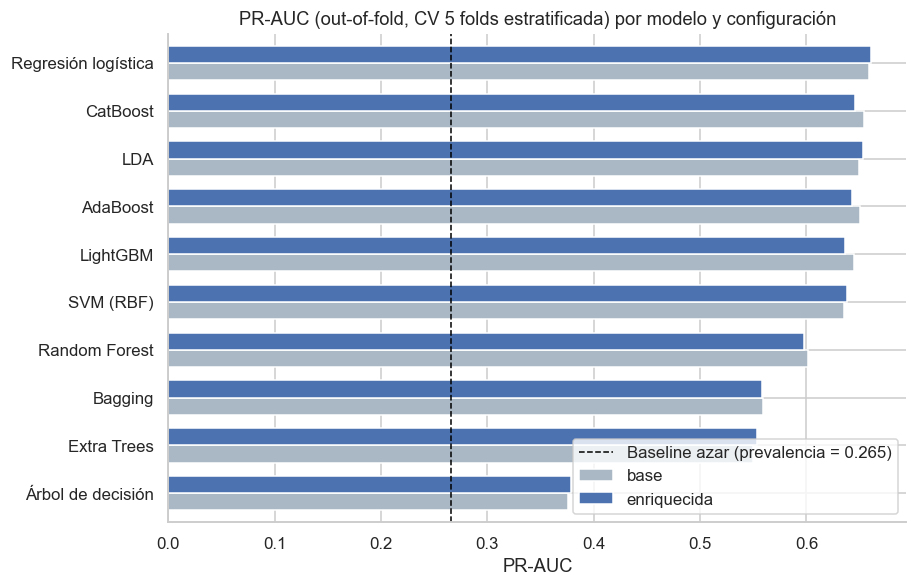

In [7]:
orden = tabla.groupby("modelo")["PR-AUC"].max().sort_values().index
fig, ax = plt.subplots(figsize=(8.5, 5.5))
pivot = tabla.pivot(index="modelo", columns="config", values="PR-AUC").loc[orden]
pivot[["base", "enriquecida"]].plot(kind="barh", ax=ax, color=["#AAB7C4", "#4C72B0"], width=0.72)
ax.axvline(y_train.mean(), color="black", ls="--", lw=1,
           label=f"Baseline azar (prevalencia = {y_train.mean():.3f})")
ax.set_title("PR-AUC (out-of-fold, CV 5 folds estratificada) por modelo y configuración")
ax.set_xlabel("PR-AUC")
ax.set_ylabel("")
ax.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

**Lectura de la tabla:**

- La **regresión logística encabeza la comparación** (PR-AUC 0,661 con features enriquecidas,
  0,659 en base): las relaciones del dataset son mayormente lineales/aditivas y con 5.634
  observaciones los modelos flexibles no encuentran mucho más para explotar.
- **CatBoost (0,654), AdaBoost (0,651), LDA (0,653) y LightGBM (0,645)** quedan a menos de
  0,02 del líder — diferencias dentro del ruido de la CV. Son los candidatos a mejorar con tuning,
  porque el boosting con defaults suele estar lejos de su techo, mientras que la logística ya está
  cerca del suyo.
- El **feature engineering ayuda a los modelos lineales** (logística y LDA mejoran) y es
  neutro-negativo para árboles y boosting, que encuentran las interacciones por su cuenta.
  Esto valida la decisión de evaluar ambas configuraciones para todos.
- El **árbol de decisión solo (PR-AUC 0,38)** confirma el overfitting esperado sin regularización;
  Bagging/Random Forest/Extra Trees con defaults quedan claramente por debajo (~0,55–0,60).

## 5. Curvas Precision-Recall de los mejores vs. baseline

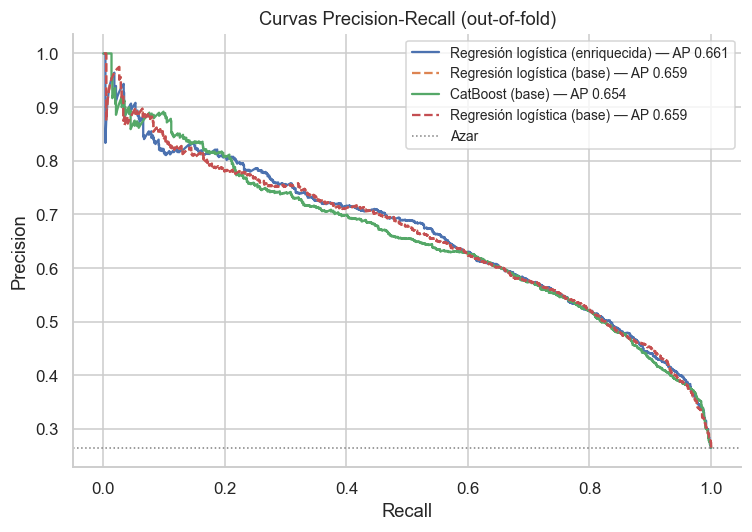

In [8]:
mejores = tabla.head(3)[["modelo", "config"]].values.tolist()
seleccion = mejores + [["Regresión logística", "base"]]

fig, ax = plt.subplots(figsize=(7, 5))
for nombre, config in seleccion:
    modelo = modelos()[nombre]
    pipe = CONFIGS[config](modelo)
    metodo = "decision_function" if isinstance(modelo, SVC) else "predict_proba"
    scores = cross_val_predict(pipe, X_train, y_train, cv=cv, method=metodo, n_jobs=-1)
    if scores.ndim == 2:
        scores = scores[:, 1]
    prec, rec, _ = precision_recall_curve(y_train, scores)
    ap = average_precision_score(y_train, scores)
    estilo = "--" if (nombre, config) == ("Regresión logística", "base") else "-"
    ax.plot(rec, prec, estilo, label=f"{nombre} ({config}) — AP {ap:.3f}")
ax.axhline(y_train.mean(), color="gray", ls=":", lw=1, label="Azar")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curvas Precision-Recall (out-of-fold)")
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

## 6. Conclusiones de la primera pasada

1. **Modelo baseline** (regresión logística, features base, defaults): PR-AUC **0,659** /
   F2 máx **0,752** — una vara alta que ningún modelo con defaults supera con claridad.
2. Los cinco mejores (logística, CatBoost, LDA, AdaBoost, LightGBM) están separados por
   menos de 0,02 de PR-AUC: la selección final se define en la fase de **boosteo**.
3. Todos los modelos superan ampliamente el azar (PR-AUC = prevalencia = 0,265).

**Próximo paso — boosteo de los mejores candidatos:** búsqueda de hiperparámetros
(`RandomizedSearchCV` optimizando average precision) sobre regresión logística, CatBoost,
LightGBM, AdaBoost y Random Forest, manejo del desbalance (`class_weight` /
`scale_pos_weight`), y elección del umbral operativo por F2. El ganador se reentrena y
evalúa una única vez sobre el test en `03_entrenar_modelo_final.ipynb`.

Quedan afuera del boosteo: **LDA** (sin hiperparámetros relevantes — su resultado ya es su
techo y es dominado por la logística), **SVM** (costoso de tunear y sin probabilidades
nativas) y **árbol / Bagging / Extra Trees** (demasiado lejos del líder; la familia de
ensambles de árboles queda representada por Random Forest, LightGBM y CatBoost).

## 7. Boosteo: búsqueda de hiperparámetros

Cinco candidatos (regresión logística, CatBoost, LightGBM, AdaBoost y Random Forest),
cada uno con las dos configuraciones de features, con `RandomizedSearchCV`
(25 combinaciones por búsqueda, mismas 5 folds estratificadas, optimizando
**average precision**). Los espacios de búsqueda incluyen el manejo del desbalance
(`class_weight` / `scale_pos_weight`).

In [9]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import clone

peso_pos = float((y_train == 0).sum() / (y_train == 1).sum())  # ~2.77

ESPACIOS = {
    "Regresión logística": (
        LogisticRegression(max_iter=4000, solver="liblinear"),
        {"clf__C": loguniform(1e-3, 1e2),
         "clf__penalty": ["l1", "l2"],
         "clf__class_weight": [None, "balanced"]},
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=SEED),
        {"clf__n_estimators": randint(200, 800),
         "clf__max_depth": [4, 6, 8, 12, 16, None],
         "clf__min_samples_leaf": randint(1, 20),
         "clf__max_features": ["sqrt", 0.3, 0.5],
         "clf__class_weight": [None, "balanced"]},
    ),
    "AdaBoost": (
        AdaBoostClassifier(random_state=SEED),
        {"clf__n_estimators": randint(100, 800),
         "clf__learning_rate": loguniform(0.01, 1),
         "clf__estimator": [DecisionTreeClassifier(max_depth=d) for d in (1, 2, 3)]},
    ),
    "LightGBM": (
        LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=1),
        {"clf__num_leaves": randint(7, 64),
         "clf__min_child_samples": randint(10, 100),
         "clf__learning_rate": loguniform(0.01, 0.3),
         "clf__n_estimators": randint(100, 800),
         "clf__reg_alpha": loguniform(1e-3, 10),
         "clf__reg_lambda": loguniform(1e-3, 10),
         "clf__subsample": uniform(0.6, 0.4),
         "clf__subsample_freq": [1],
         "clf__colsample_bytree": uniform(0.6, 0.4),
         "clf__scale_pos_weight": [1.0, peso_pos]},
    ),
    "CatBoost": (
        CatBoostClassifier(random_state=SEED, verbose=0,
                           allow_writing_files=False, thread_count=1),
        {"clf__depth": randint(3, 9),
         "clf__learning_rate": loguniform(0.01, 0.3),
         "clf__iterations": randint(200, 800),
         "clf__l2_leaf_reg": loguniform(1, 30),
         "clf__scale_pos_weight": [1.0, peso_pos]},
    ),
}

res_tuning, mejores_params = [], {}
for nombre, (modelo, espacio) in ESPACIOS.items():
    for config, construir in CONFIGS.items():
        rs = RandomizedSearchCV(construir(clone(modelo)), espacio, n_iter=25,
                                scoring="average_precision", cv=cv, n_jobs=-1,
                                random_state=SEED, refit=False)
        t0 = time.time()
        rs.fit(X_train, y_train)
        segundos = time.time() - t0
        default = tabla.query("modelo == @nombre and config == @config")["PR-AUC"].iloc[0]
        res_tuning.append({"modelo": nombre, "config": config,
                           "PR-AUC default": default, "PR-AUC tuned": rs.best_score_,
                           "mejora": rs.best_score_ - default, "seg": segundos})
        mejores_params[(nombre, config)] = rs.best_params_
        print(f"{nombre:22s} {config:12s} tuned={rs.best_score_:.4f} "
              f"(default={default:.4f}, {segundos:.0f}s)")

tabla_tuning = (pd.DataFrame(res_tuning)
                .sort_values("PR-AUC tuned", ascending=False)
                .reset_index(drop=True))

Regresión logística    base         tuned=0.6618 (default=0.6585, 4s)


Regresión logística    enriquecida  tuned=0.6641 (default=0.6609, 5s)


Random Forest          base         tuned=0.6669 (default=0.6019, 101s)


Random Forest          enriquecida  tuned=0.6632 (default=0.5976, 119s)


AdaBoost               base         tuned=0.6697 (default=0.6506, 162s)


AdaBoost               enriquecida  tuned=0.6632 (default=0.6431, 215s)


LightGBM               base         tuned=0.6721 (default=0.6449, 16s)


LightGBM               enriquecida  tuned=0.6674 (default=0.6359, 16s)


CatBoost               base         tuned=0.6710 (default=0.6539, 113s)


CatBoost               enriquecida  tuned=0.6669 (default=0.6455, 111s)


In [10]:
tabla_tuning.round(4).style\
    .background_gradient(subset=["PR-AUC tuned"], cmap="Blues")\
    .format({"PR-AUC default": "{:.4f}", "PR-AUC tuned": "{:.4f}",
             "mejora": "{:+.4f}", "seg": "{:.0f}"})

,modelo,config,PR-AUC default,PR-AUC tuned,mejora,seg
0,LightGBM,base,0.6449,0.6721,+0.0272,16
1,CatBoost,base,0.6539,0.6710,+0.0170,113
2,AdaBoost,base,0.6506,0.6697,+0.0191,162
3,LightGBM,enriquecida,0.6359,0.6674,+0.0315,16
4,CatBoost,enriquecida,0.6455,0.6669,+0.0214,111
5,Random Forest,base,0.6019,0.6669,+0.0650,101
6,Regresión logística,enriquecida,0.6609,0.6641,+0.0032,5
7,AdaBoost,enriquecida,0.6431,0.6632,+0.0201,215
8,Random Forest,enriquecida,0.5976,0.6632,+0.0656,119
9,Regresión logística,base,0.6585,0.6618,+0.0033,4


In [11]:
ganador = tabla_tuning.iloc[0]
params_ganador = mejores_params[(ganador["modelo"], ganador["config"])]
print(f"Mejor modelo: {ganador['modelo']} ({ganador['config']}) — "
      f"PR-AUC {ganador['PR-AUC tuned']:.4f}")
print("Hiperparámetros:")
for k, v in sorted(params_ganador.items()):
    print(f"  {k.replace('clf__', '')}: {v}")

Mejor modelo: LightGBM (base) — PR-AUC 0.6721
Hiperparámetros:
  colsample_bytree: 0.6296178606936361
  learning_rate: 0.0338452204120114
  min_child_samples: 50
  n_estimators: 127
  num_leaves: 13
  reg_alpha: 2.512779099948728
  reg_lambda: 0.0627773091695805
  scale_pos_weight: 1.0
  subsample: 0.6254233401144095
  subsample_freq: 1


**Lectura del boosteo:**

- **El tuning cambia el podio:** LightGBM base pasa al frente (0,645 → **0,672**), seguido por
  CatBoost (0,671) y AdaBoost (0,670). La logística casi no mejora (+0,003) — ya estaba cerca
  de su techo — y queda quinta (0,664). Se confirma la hipótesis: el boosting con defaults
  estaba lejos de su potencial.
- **Random Forest pegó el mayor salto (+0,065):** con defaults sobreajustaba (árboles sin
  límite de profundidad); regularizado se vuelve competitivo (0,667). Valió la pena incluirlo
  en la búsqueda en lugar de descartarlo por su resultado default.
- **Los hiperparámetros del ganador cuentan una historia coherente** con un dataset de
  5.634 filas: fuerte regularización — solo 13 hojas, mínimo de 50 observaciones por hoja,
  learning rate bajo (0,034) con apenas 127 árboles, y submuestreo de filas y columnas (~0,63).
- **`scale_pos_weight = 1`:** el re-pesado de clases no ayudó a la métrica; el desbalance se
  maneja mejor vía la elección del umbral (sección siguiente).
- La configuración **base** gana en todos los modelos de árboles; la **enriquecida** solo
  aporta a los lineales, consistente con la primera pasada.
- El top 3 está separado por ~0,002 de PR-AUC — dentro del ruido de CV. Se elige LightGBM
  por score; la logística queda como alternativa razonable si se priorizara interpretabilidad
  directa (coeficientes) sobre performance.

## 8. Umbral operativo por F2

El modelo elegido produce un score de riesgo; para accionar hay que fijar el **umbral** a
partir del cual un cliente se considera "en riesgo". Se elige el que maximiza **F2** sobre las
predicciones out-of-fold (recall pesa 4 veces más que precision, coherente con el caso de
negocio: es peor no contactar a un churner que hacer una oferta de más).

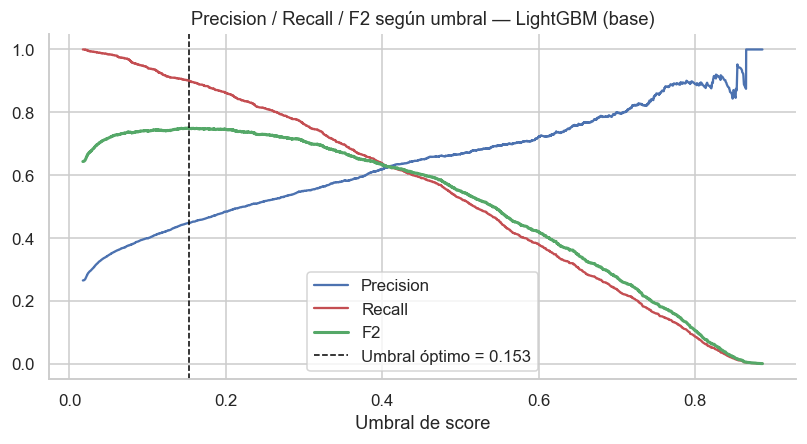

In [12]:
from sklearn.metrics import confusion_matrix, fbeta_score, precision_score, recall_score

pipe_final = CONFIGS[ganador["config"]](clone(ESPACIOS[ganador["modelo"]][0]))
pipe_final.set_params(**params_ganador)

scores_oof = cross_val_predict(pipe_final, X_train, y_train, cv=cv,
                               method="predict_proba", n_jobs=-1)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, scores_oof)
f2_curva = (5 * prec * rec) / np.where((4 * prec + rec) == 0, np.nan, 4 * prec + rec)
i_opt = np.nanargmax(f2_curva[:-1])
umbral_opt = thr[i_opt]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(thr, prec[:-1], label="Precision", color="#4C72B0")
ax.plot(thr, rec[:-1], label="Recall", color="#C44E52")
ax.plot(thr, f2_curva[:-1], label="F2", color="#55A868", lw=2)
ax.axvline(umbral_opt, color="black", ls="--", lw=1,
           label=f"Umbral óptimo = {umbral_opt:.3f}")
ax.set_xlabel("Umbral de score")
ax.set_title(f"Precision / Recall / F2 según umbral — {ganador['modelo']} ({ganador['config']})")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

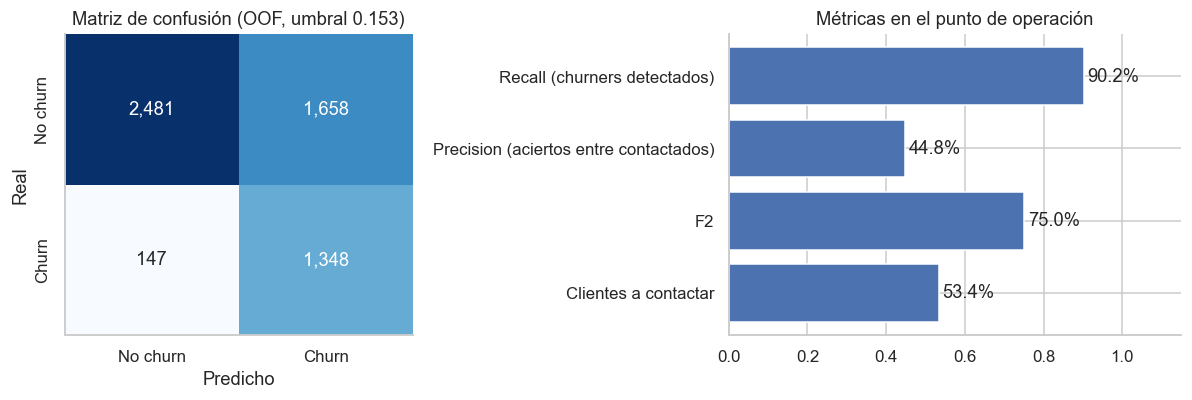

Umbral: 0.153 | Recall: 0.902 | Precision: 0.448 | F2: 0.750 | % contactados: 0.534


In [13]:
pred_opt = (scores_oof >= umbral_opt).astype(int)
cm = confusion_matrix(y_train, pred_opt)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), width_ratios=[1, 1.3])
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"])
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")
axes[0].set_title(f"Matriz de confusión (OOF, umbral {umbral_opt:.3f})")

resumen_umbral = pd.Series({
    "Recall (churners detectados)": recall_score(y_train, pred_opt),
    "Precision (aciertos entre contactados)": precision_score(y_train, pred_opt),
    "F2": fbeta_score(y_train, pred_opt, beta=2),
    "Clientes a contactar": pred_opt.mean(),
})
axes[1].barh(resumen_umbral.index[::-1], resumen_umbral.values[::-1], color="#4C72B0")
for i, v in enumerate(resumen_umbral.values[::-1]):
    axes[1].text(v + 0.01, i, f"{v:.1%}", va="center")
axes[1].set_xlim(0, 1.15)
axes[1].set_title("Métricas en el punto de operación")
sns.despine()
plt.tight_layout()
plt.show()

print(f"Umbral: {umbral_opt:.3f} | Recall: {recall_score(y_train, pred_opt):.3f} | "
      f"Precision: {precision_score(y_train, pred_opt):.3f} | "
      f"F2: {fbeta_score(y_train, pred_opt, beta=2):.3f} | "
      f"% contactados: {pred_opt.mean():.3f}")

### Experimentos adicionales: ensambles y CatBoost nativo

Para agotar las alternativas antes de fijar el modelo final se probaron tres configuraciones
más (PR-AUC sobre predicciones out-of-fold agrupadas, mismas 5 folds; con esta forma de
agregación el LightGBM tuneado da 0,6686 — levemente distinto del promedio por fold de la
tabla anterior):

| Candidato | PR-AUC (OOF) | F2 máx |
|---|---|---|
| LightGBM tuneado (referencia) | 0,6686 | 0,7501 |
| Voting LGBM + CatBoost + AdaBoost | **0,6699** | 0,7495 |
| Stacking (meta-modelo: reg. logística) | 0,6691 | 0,7499 |
| CatBoost con categóricas nativas (tuneado) | 0,6685 | 0,7510 |

Ninguna alternativa supera al LightGBM por un margen que justifique el costo: el Voting gana
+0,0013 (dentro del ruido de CV) a cambio de triplicar la complejidad, y el CatBoost nativo
—que procesa las categóricas sin one-hot— empata. **Decisión: se mantiene LightGBM como
modelo final** por parsimonia, velocidad y facilidad de interpretación (SHAP directo).

### Experimento adicional: feature engineering v2

Se probó un set más agresivo de features derivadas sobre el LightGBM tuneado
(conteos de servicios de protección y streaming, flags de cliente nuevo, pago automático
y mes-a-mes × fibra, gasto promedio histórico `TotalCharges/tenure` y su delta contra el
cargo actual como proxy de aumentos de precio):

| Configuración de features | PR-AUC (OOF agrupado) |
|---|---|
| **Base (final)** | **0,6686** |
| Enriquecida v1 | 0,6625 |
| Enriquecida v2 | 0,6603 |
| Enriquecida v2 + re-tuning de hiperparámetros | 0,6603 |

Todas las variantes de feature engineering **empeoran** al modelo: con ~5.600 observaciones,
las features derivadas agregan dimensiones sin información nueva (son funciones de las
crudas) y el boosting ya captura esas interacciones por sí solo. Confirma la elección de las
features base para el modelo final.

## 9. Conclusiones de la selección de modelos

1. **Modelo final: LightGBM con features base e hiperparámetros regularizados** —
   PR-AUC out-of-fold **0,672**, contra 0,659 del baseline (regresión logística default).
   Se compararon 10 algoritmos × 2 configuraciones de features con defaults, y los 5 mejores
   se optimizaron con búsqueda aleatoria de hiperparámetros (30 configuraciones evaluadas
   en total por CV de 5 folds, todas contra la misma partición).
2. **Punto de operación (umbral 0,153, elegido por F2):** recall **90%** — se detectan 9 de
   cada 10 churners — con precision del **45%** (F2 = 0,750). Implica accionar sobre ~53% de
   la cartera: si la capacidad del equipo de retención es menor, el mismo score permite
   priorizar los N clientes de mayor riesgo — **el umbral es una decisión de negocio; el
   modelo entrega el ranking**.
3. El test (20%, 1.409 clientes) sigue **intacto**: se usa una única vez en
   `03_entrenar_modelo_final.ipynb` para estimar el rendimiento del modelo final.